In [1]:
!pip install bert-score

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from bert_score import score as bertscore_score

output_path = Path("/home/a/arfaoui/rag_project/Output_1B")


BERTScore_summary_csv = output_path / "all_experiment_bertscore_experiment.csv"

print("Reading experiment folders from:", output_path)

/home/a/arfaoui/miniconda3/envs/AAML/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading experiment folders from: /home/a/arfaoui/rag_project/Output_1B


In [12]:
def load_json(path):
    """
    Load a standard JSON file.
    """
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_jsonl(path):
    """
    Load a JSONL file (one JSON object per line).
    """
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows





def compute_average_bertscore(df, lang="en"):
    """
    Compute average BERTScore F1 for one experiment run.

    """
    preds = df["prediction"].fillna("").astype(str).tolist()
    refs = df["correct_answer"].fillna("").astype(str).tolist()

    p, r, f1 = bertscore_score(preds, refs, lang=lang, verbose=False)

    return float(p.mean()), float(r.mean()), float(f1.mean())

In [13]:

# Compute BERTScore
summary_rows = []

experiment_folders = [p for p in output_path.iterdir() if p.is_dir()]
print("Found folders:", len(experiment_folders))

for predictions_path in sorted(output_path.glob("*/predictions.jsonl")):
    folder = predictions_path.parent
    summary_path = folder / "summary.json"

   

    print(f"Processing {folder.name} ...")

    predictions = load_jsonl(predictions_path)
    summary = load_json(summary_path)

    df_run = pd.DataFrame(predictions)

    

    # Compute BERTScore
    avg_bertscore_f1, avg_bertscore_p, avg_bertscore_r = compute_average_bertscore(df_run)

    # Extract config
    chunk_size = summary.get("chunk_size")
    top_k = summary.get("top_k")

    # Build CLEAN summary row (ONLY BERTScore)
    row = {
        "model_name": "llama_3.2_1b",
        "chunk_size": chunk_size,
        "top_k": top_k,
        "num_examples": summary.get("num_examples"),
        "avg_BERTScore_F1": avg_bertscore_f1,
        "avg_BERTScore_P": avg_bertscore_p,
        "avg_BERTScore_R": avg_bertscore_r,
        
    }

    summary_rows.append(row)

print("Finished processing all experiment folders.")

Found folders: 10
Processing chunk_128_topk_1 ...


/home/a/arfaoui/miniconda3/envs/AAML/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Processing chunk_128_topk_10 ...


/home/a/arfaoui/miniconda3/envs/AAML/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Processing chunk_128_topk_5 ...


...

Processing chunk_32_topk_10 ...


/home/a/arfaoui/miniconda3/envs/AAML/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Processing chunk_32_topk_5 ...


/home/a/arfaoui/miniconda3/envs/AAML/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Finished processing all experiment folders.


In [14]:
df_summary = pd.DataFrame(summary_rows)

df_summary = df_summary.sort_values(by=["chunk_size", "top_k"])
df_summary.to_csv(BERTScore_summary_csv , index=False)

print("Saved BERTScore summary file to:", BERTScore_summary_csv )
display(df_summary)


Saved BERTScore summary file to: /home/a/arfaoui/rag_project/Output_1B/all_experiment_bertscore_experiment.csv


,model_name,chunk_size,top_k,num_examples,avg_BERTScore_F1,avg_BERTScore_P,avg_BERTScore_R
6,llama_3.2_1b,32,1,500,0.861512,0.864521,0.862023
8,llama_3.2_1b,32,5,500,0.868774,0.874002,0.870426
7,llama_3.2_1b,32,10,500,0.868843,0.875191,0.871115
0,llama_3.2_1b,128,1,500,0.862585,0.869217,0.865014
2,llama_3.2_1b,128,5,500,0.876091,0.883958,0.879103
1,llama_3.2_1b,128,10,500,0.873879,0.882983,0.877569
3,llama_3.2_1b,256,1,500,0.860835,0.866205,0.862611
5,llama_3.2_1b,256,5,500,0.875885,0.883449,0.878825
4,llama_3.2_1b,256,10,500,0.877761,0.883925,0.880042


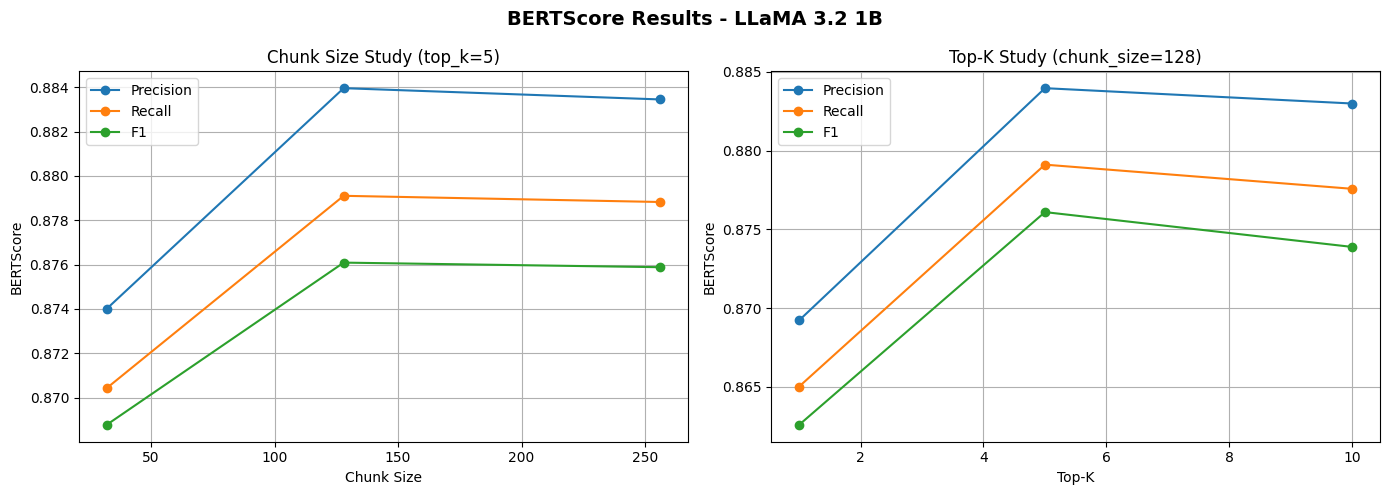

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("BERTScore Results - LLaMA 3.2 1B", fontsize=14, fontweight="bold")

chunk_study = df_summary[df_summary["top_k"] == 5].sort_values("chunk_size")
topk_study  = df_summary[df_summary["chunk_size"] == 128].sort_values("top_k")

for col, label in zip(["avg_BERTScore_P", "avg_BERTScore_R", "avg_BERTScore_F1"], ["Precision", "Recall", "F1"]):
    axes[0].plot(chunk_study["chunk_size"], chunk_study[col], marker="o", label=label)
    axes[1].plot(topk_study["top_k"],       topk_study[col],  marker="o", label=label)

axes[0].set_title("Chunk Size Study (top_k=5)")
axes[0].set_xlabel("Chunk Size")
axes[1].set_title("Top-K Study (chunk_size=128)")
axes[1].set_xlabel("Top-K")

for ax in axes:
    ax.set_ylabel("BERTScore")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(output_path / "bertscore_study.png", dpi=150)
plt.show()